In [237]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

In [190]:
df1 = pd.read_csv("data//dog_breeds_from_kaggle.csv")
df2 = pd.read_csv("data//dog_breeds_dog_api_clean.csv")

In [191]:
df = pd.merge(df1,df2,left_on="Name",right_on="name",how="left",indicator=True)

In [192]:
df.shape

(159, 34)

In [193]:
df["_merge"].value_counts()

_merge
both          144
left_only      15
right_only      0
Name: count, dtype: int64

In [194]:
check_merge.loc[check_merge["_merge"] == "left_only", "Name"]

6                   American Eskimo
16                     Bichon Frise
27                 Brussels Griffon
42                           Collie
48                  English Bulldog
53              English Toy Spaniel
68                   Great Pyrenees
91                          Lowchen
94                          Mastiff
108    Petit Basset Griffon Vendeen
113               Poodle (Standard)
134                   Silky Terrier
138     Soft-Coated Wheaten Terrier
142                 Standard Poodle
155            Wirehaired Dachshund
Name: Name, dtype: str

In [195]:
# Check if problem was capital letters or spaces
df1["breed_key"] = df1["Name"].str.lower().str.strip()
df2["breed_key"] = df2["name"].str.lower().str.strip()

In [196]:
df1["breed_key"].isin(df2["breed_key"]).value_counts()

breed_key
True     144
False     15
Name: count, dtype: int64

In [197]:
# Get close matches
from difflib import get_close_matches

dogapi_names = df2["name"].dropna().tolist()

for breed in unmatched:
    matches = get_close_matches(breed, dogapi_names, n=3, cutoff=0.)

    print(f"{breed}: {matches}")

American Eskimo: ['American Eskimo Dog', 'American Bulldog', 'American Foxhound']
Bichon Frise: ['Bichon Frisé', 'Boston Terrier', 'Bedlington Terrier']
Brussels Griffon: ['Briquet Griffon Vendéen', 'Petit Basset Griffon Vendéen', 'Grand Basset Griffon Vendéen']
Collie: ['Sprollie', 'Rough Collie', 'Koolie']
English Bulldog: ['Olde English Bulldogge', 'French Bulldog', 'Bulldog']
English Toy Spaniel: ['English Cocker Spaniel', 'English Springer Spaniel', 'Irish Water Spaniel']
Great Pyrenees: ['Great Dane', 'Briquet de Provence', 'Carea Leonés']
Lowchen: ['Löwchen', 'Poochon', 'Lurcher']
Mastiff: ['Bullmastiff', 'Tibetan Mastiff', 'Spanish Mastiff']
Petit Basset Griffon Vendeen: ['Petit Basset Griffon Vendéen', 'Grand Basset Griffon Vendéen', 'Briquet Griffon Vendéen']
Poodle (Standard): ['Poodle (Miniature)', 'Poodle (Toy)', 'Podenco Canario']
Silky Terrier: ['Skye Terrier', 'Cesky Terrier', 'Sealyham Terrier']
Soft-Coated Wheaten Terrier: ['Soft Coated Wheaten Terrier', 'Flat-Coated 

In [198]:
df1.loc[df1["Name"].str.contains(
        "Collie",
        case=False,
        na=False
    ), "Name"]

14    Bearded Collie
19     Border Collie
42            Collie
Name: Name, dtype: str

In [199]:
df1.loc[
    df1["Name"].isin(['Collie', 'Bearded Collie', 'Border Collie'])
].T

,14,19,42
Name,Bearded Collie,Border Collie,Collie
Origin,Scotland,UK,Scotland
Type,Herding,Herding,Herding
Unique Feature,Long shaggy coat,Highest intelligence,Lassie fame
Friendly Rating (1-10),8,8,9
Life Span,13,13,13
Size,Medium,Medium,Medium
Grooming Needs,Very High,High,High
Exercise Requirements (hrs/day),2.0,3.0,2.0
Good with Children,Yes,Yes,Yes


In [200]:
df2.loc[
    df2["name"].isin(['Bearded Collie', 'Border Collie','Rough Collie', 'Smooth Collie'])
].T

,64,89,490,546
name,Bearded Collie,Border Collie,Rough Collie,Smooth Collie
species_id,2,2,2,2
temperament,"intelligent, energetic, playful, affectionate,...","intelligent, energetic, alert, work-focused, l...","intelligent, loyal, devoted, gentle, protectiv...","intelligent, loyal, gentle, friendly, devoted"
origin,Scotland,Anglo-Scottish border region,Scotland,Scotland and Northern England
country_code,GB,GB,GB,GB
description,"Medium-sized herding dog with long, shaggy dou...","Medium-sized, highly intelligent, and athletic...",An elegant and graceful large herding dog with...,Medium to large graceful herding dog with shor...
breed_group,Herding,Herding,Herding,Herding
history,Ancient Scottish herding breed developed to dr...,Developed by shepherds on the border of Englan...,Developed in the Scottish Highlands and Northe...,Developed in the Scottish Highlands and Northe...
image,"{'id': 'BjFmVohkU', 'url': 'https://cdn2.thedo...","{'id': '38KoA9gGB', 'url': 'https://cdn2.thedo...","{'id': 'WSxoPB2xcZ', 'url': 'https://cdn4.thed...","{'id': 'UDfnMbIhDx', 'url': 'https://cdn4.thed..."
weight_min_kg,20.0,14.0,23.0,23.0


In [201]:
df2['name'] = df2['name'].replace({"Miniature Dachshund": "Dachshund"})

In [202]:
df2 = df2.drop_duplicates(subset="name", keep="first")

In [203]:
# Uniformise breed names in both data sets
breed_mapping = {"American Eskimo": "American Eskimo Dog",
    "Bichon Frise": "Bichon Frisé",
    "English Bulldog": "Bulldog",
    "Lowchen": "Löwchen",
    "Petit Basset Griffon Vendeen": "Petit Basset Griffon Vendéen",
    "Soft-Coated Wheaten Terrier": "Soft Coated Wheaten Terrier",
    "Poodle (Standard)": "Standard Poodle"}

df1['breed_match'] = df1['Name']
df1['breed_match'] = df1["Name"].replace(breed_mapping)

In [204]:
df = pd.merge(df1,df2,
    left_on="breed_match",
    right_on="name",
    how="inner")

In [205]:
df.shape

(150, 36)

In [206]:
df.isnull().sum()

Name                                0
Origin                              0
Type                                0
Unique Feature                      0
Friendly Rating (1-10)              0
Life Span                           0
Size                                0
Grooming Needs                      0
Exercise Requirements (hrs/day)     0
Good with Children                  0
Intelligence Rating (1-10)          0
Shedding Level                      0
Health Issues Risk                  0
Average Weight (kg)                 0
Training Difficulty (1-10)          0
breed_key_x                         0
breed_match                         0
name                                0
species_id                          0
temperament                         0
origin                              0
country_code                        0
description                         0
breed_group                         0
history                             0
image                               0
weight_min_k

In [207]:
df.head()

,Name,Origin,Type,Unique Feature,Friendly Rating (1-10),Life Span,Size,Grooming Needs,Exercise Requirements (hrs/day),Good with Children,...,weight_min_kg,weight_max_kg,weight_avg_kg,height_min_cm,height_max_cm,height_mid_cm,life_span_min_years,life_span_max_years,life_span_mid_years,breed_key_y
0,Affenpinscher,Germany,Toy,Monkey-like face,7,14,Small,High,1.5,Yes,...,3.2,4.5,3.85,23.0,29.0,26.0,12.0,15.0,13.5,affenpinscher
1,Afghan Hound,Afghanistan,Hound,Long silky coat,5,13,Large,Very High,2.0,No,...,20.0,30.0,25.00,63.0,74.0,68.5,12.0,15.0,13.5,afghan hound
2,Airedale Terrier,England,Terrier,Largest of terriers,8,12,Medium,High,2.0,Yes,...,18.0,32.0,25.00,56.0,61.0,58.5,11.0,14.0,12.5,airedale terrier
3,Akita,Japan,Working,Strong loyalty,6,11,Large,Moderate,2.0,With Training,...,32.0,59.0,45.50,61.0,71.0,66.0,10.0,13.0,11.5,akita
4,Alaskan Malamute,Alaska USA,Working,Strong pulling ability,7,11,Large,High,3.0,Yes,...,32.0,41.0,36.50,56.0,66.0,61.0,10.0,14.0,12.0,alaskan malamute


In [208]:
# Drop unnecessary columns
df.drop(['Life Span','Average Weight (kg)', 'breed_key_x',
       'breed_match', 'name', 'species_id', 'breed_key_y'], axis=1, inplace=True)

In [209]:
df['temperament list'] = df['temperament'].apply(lambda x: x.split(',') if type(x)==str else [])

In [210]:
temperament = [item.strip().lower() for sublist in df['temperament list'] if len(sublist) > 0 for item in sublist]
temperament= set(temperament)

In [211]:
len(temperament)

39

In [212]:
# Grouping temperaments
temperament_categories = {
    "affection_sociability": [
        "affectionate", "friendly", "devoted", "amiable",
        "good-natured", "outgoing", "happy", "merry", "charming"
    ],
    "energy_activity": [
        "energetic", "athletic", "lively",
        "spirited", "active", "agile"
    ],
    "trainability": [
        "intelligent", "smart", "clever",
        "eager to please", "work-focused"
    ],
    "playfulness": [
        "playful", "mischievous", "curious"
    ],
    "protectiveness": [
        "protective", "alert", "courageous", "fearless"
    ],
    "independence": [
        "independent", "aloof", "reserved", "tenacious"
    ],
    "calm_stability": [
        "calm", "gentle", "docile",
        "patient", "even-tempered", "adaptable"
    ],
    "confidence_resilience": [
        "confident", "hardy", "optimistic", "dignified"
    ]
}

In [213]:
df["temperament_clean"] = (df["temperament"].fillna("").str.lower())

for category, words in temperament_categories.items():
    df[category] = df["temperament_clean"].apply(
        lambda x: int(any(word in [t.strip() for t in x.split(",")] for word in words)))

In [214]:
df["temperament_clean"] = (
    df["temperament"]
    .fillna("")
    .str.lower()
)

for category, words in temperament_categories.items():
    df[category] = df["temperament_clean"].apply(lambda x: int(any(word in [t.strip() for t in x.split(",")] for word in words)))

In [215]:
# Save temperament categories for future reference
import json
with open("temperament_categories.json", "w", encoding="utf-8") as file:
    json.dump(temperament_categories, file, indent=4)

In [224]:
# Extract image address
def extract_image_url(value):
    if pd.isna(value):
        return None

    try:
        image_dict = ast.literal_eval(value)
        return image_dict.get("url")
    except (ValueError, SyntaxError):
        return None

df["image_url"] = df["image"].apply(extract_image_url)

,Name,Origin,Type,Unique Feature,Friendly Rating (1-10),Size,Grooming Needs,Exercise Requirements (hrs/day),Good with Children,Intelligence Rating (1-10),...,temperament_clean,affection_sociability,energy_activity,trainability,playfulness,protectiveness,independence,calm_stability,confidence_resilience,image_url
0,Affenpinscher,Germany,Toy,Monkey-like face,7,Small,High,1.5,Yes,8,...,"confident, alert, playful, loyal, courageous",0,0,0,1,1,0,0,1,https://cdn2.thedogapi.com/images/0LJiOVlxp.jpg
1,Afghan Hound,Afghanistan,Hound,Long silky coat,5,Large,Very High,2.0,No,4,...,"independent, dignified, aloof, loyal, confident",0,0,0,0,0,1,0,1,https://cdn2.thedogapi.com/images/tChrH8dDJ.jpg
2,Airedale Terrier,England,Terrier,Largest of terriers,8,Medium,High,2.0,Yes,7,...,"confident, intelligent, courageous, alert, ene...",1,1,1,0,1,0,0,1,https://cdn2.thedogapi.com/images/QWRBrrIvB.jpg
3,Akita,Japan,Working,Strong loyalty,6,Large,Moderate,2.0,With Training,7,...,"courageous, loyal, dignified, independent, pro...",0,0,0,0,1,1,0,1,https://cdn2.thedogapi.com/images/iNX25KsSX.jpg
4,Alaskan Malamute,Alaska USA,Working,Strong pulling ability,7,Large,High,3.0,Yes,6,...,"affectionate, friendly, loyal, playful, intell...",1,1,1,1,0,0,0,0,https://cdn2.thedogapi.com/images/GhtSdrW29.jpg


In [225]:
df.to_csv("data\\dog_breeds_clean.csv", index=False)

In [229]:
# “Is there really a perfect apartment dog?” 
# Compare size against energy, exercise requirements, grooming, trainability and temperament. 
#You might find that some small breeds are actually less suitable for a quiet lifestyle than larger calm breeds.

C:\Users\ferna\AppData\Local\Temp\ipykernel_2596\2569984977.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x= df['Friendly Rating (1-10)'], y=df['Intelligence Rating (1-10)'], palette="inferno")
C:\Users\ferna\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 51.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\ferna\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 41.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='Friendly Rating (1-10)', ylabel='Intelligence Rating (1-10)'>

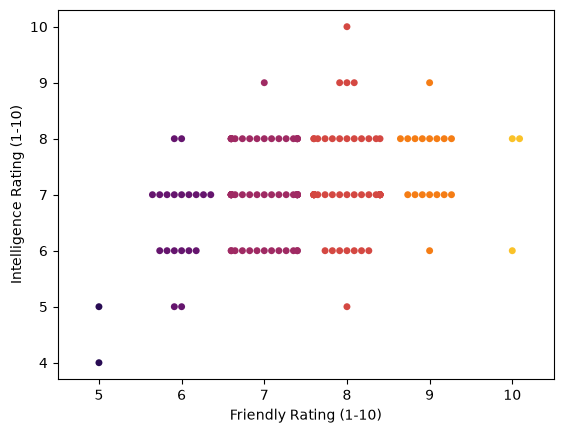

In [261]:
sns.swarmplot(data=df, x= df['Friendly Rating (1-10)'], y=df['Intelligence Rating (1-10)'], palette="inferno")

<Axes: xlabel='height_mid_cm', ylabel='weight_avg_kg'>

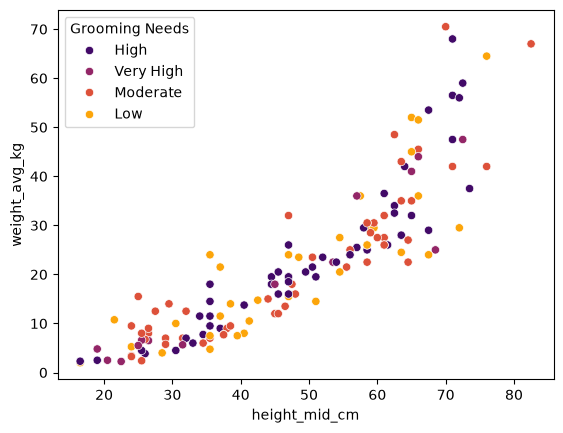

In [245]:
# “Small dog, big personality?” Compare weight/height with confidence, protectiveness, energy and independence. 
#That could make a very fun scatter plot.
temperament_vector = [['confidence_resilience', 'energy_activity','protectiveness', 'independence']]
sns.scatterplot(data=df, x= df.height_mid_cm, y=df.weight_avg_kg, hue= 'Grooming Needs',palette="inferno")

In [219]:
# “Are bigger dogs really calmer?”, plotting weight against exercise requirements and your calm_stability category.

In [220]:
# “Brains vs obedience” could compare Kaggle's intelligence rating with training difficulty and your eager to please/independence-related temperament features.

In [221]:
# “Family dog sweet spot” could look at good-with-children, friendliness, affection/sociability, playfulness, size and training difficulty.

# And “High maintenance, but worth it?” could compare grooming requirements, exercise requirements and training difficulty against friendliness/intelligence/lifespan.

In [226]:
print(df.columns.tolist())

['Name', 'Origin', 'Type', 'Unique Feature', 'Friendly Rating (1-10)', 'Size', 'Grooming Needs', 'Exercise Requirements (hrs/day)', 'Good with Children', 'Intelligence Rating (1-10)', 'Shedding Level', 'Health Issues Risk', 'Training Difficulty (1-10)', 'temperament', 'origin', 'country_code', 'description', 'breed_group', 'history', 'image', 'weight_min_kg', 'weight_max_kg', 'weight_avg_kg', 'height_min_cm', 'height_max_cm', 'height_mid_cm', 'life_span_min_years', 'life_span_max_years', 'life_span_mid_years', 'temperament list', 'temperament_clean', 'affection_sociability', 'energy_activity', 'trainability', 'playfulness', 'protectiveness', 'independence', 'calm_stability', 'confidence_resilience', 'image_url']
